# 🏥 Healthcare Operations — Advanced Analytics
**Author:** Aditya · M.S. Applied Data Science · Syracuse University · 2026  
**Prerequisite:** Run `healthcare_data_cleaning.ipynb` first to generate `healthcare_master.csv`  

## What this notebook builds:
1. **Regression Model** — Predict patient satisfaction score from operational metrics
2. **K-Means Clustering** — Segment hospitals into operational profiles
3. **Spending Correlation** — Cost vs Quality analysis using CMS spending data

> All outputs are exported as CSVs to Google Drive for Power BI integration.

---
## Section 1 — Setup

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy requests -q

import os, warnings, requests, io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Sklearn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Plot style ──────────────────────────────────────────────────────────────
DARK_BG   = '#0d1117'
SURFACE   = '#111118'
SURFACE2  = '#18181f'
BORDER    = '#252530'
TEXT      = '#e6edf3'
MUTED     = '#7d8fa1'
P1        = '#7b61ff'
P2        = '#00c9a7'
P3        = '#ff6b6b'
P4        = '#ffa94d'
P5        = '#4dabf7'
PALETTE   = [P5, P2, P4, P3, P1]

def style_ax(ax):
    ax.set_facecolor(SURFACE)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.title.set_color(TEXT)
    ax.grid(color=BORDER, linewidth=0.5, alpha=0.7)

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [2]:
# ── Mount Drive & load master dataset ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

BASE   = '/content/drive/MyDrive/healthcare-dashboard'
CLEAN  = f'{BASE}/data/clean'
ASSETS = f'{BASE}/assets'
os.makedirs(ASSETS, exist_ok=True)

master = pd.read_csv(f'{CLEAN}/healthcare_master.csv', low_memory=False)
print(f'✅ Master dataset loaded: {master.shape[0]:,} rows × {master.shape[1]} cols')
print(f'   Columns: {list(master.columns)}')

Mounted at /content/drive
✅ Master dataset loaded: 5,366 rows × 32 cols
   Columns: ['facility_id', 'facility_name', 'state', 'hospital_type', 'hospital_ownership', 'emergency_services', 'hospital_overall_rating', 'COMP_HIP_KNEE', 'MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 'H_CLEAN_HSP_A_P', 'H_COMP_1_A_P', 'H_COMP_2_A_P', 'H_COMP_5_A_P', 'H_COMP_6_Y_P', 'H_HSP_RATING_9_10', 'H_QUIET_HSP_A_P', 'H_RECMND_DY', 'READM_30_AMI', 'READM_30_HF', 'READM_30_PN', 'composite_satisfaction_score', 'performance_tier', 'satisfaction_tier', 'IMM_3', 'OP_18a', 'OP_18b', 'OP_22', 'OP_23', 'avg_er_wait_minutes', 'er_inefficiency_flag']


---
## Section 2 — Regression Model
### Predict Composite Patient Satisfaction Score
**Goal:** Identify which operational metrics most strongly predict patient satisfaction.  
**Clinical relevance:** Hospitals can use this to prioritize interventions that maximize satisfaction impact.

In [3]:
# ── Feature selection for regression ───────────────────────────────────────
TARGET = 'composite_satisfaction_score'

# Candidate predictors — operational & quality metrics
CANDIDATE_FEATURES = [
    'avg_er_wait_minutes', 'er_inefficiency_flag',
    'hospital_overall_rating',
    'MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN',
    'READM_30_HOSP', 'READM_30_AMI', 'READM_30_HF',
    'high_readmission_flag',
    'OP_18b', 'OP_22',
    'COMP_HIP_KNEE', 'PSI_90_SAFETY',
]

# Keep only features that exist in master
features = [f for f in CANDIDATE_FEATURES if f in master.columns]
print(f'Features available for regression ({len(features)}): {features}')

# Build modeling dataset
model_df = master[[TARGET] + features].copy()
model_df = model_df.dropna(subset=[TARGET])

# Impute remaining nulls with median
imputer = SimpleImputer(strategy='median')
X_raw = model_df[features]
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=features)
y = model_df[TARGET].values

print(f'\nModeling dataset: {X_imputed.shape[0]:,} hospitals')
print(f'Target range: {y.min():.1f}% – {y.max():.1f}%  |  Mean: {y.mean():.1f}%')

Features available for regression (11): ['avg_er_wait_minutes', 'er_inefficiency_flag', 'hospital_overall_rating', 'MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 'READM_30_AMI', 'READM_30_HF', 'OP_18b', 'OP_22', 'COMP_HIP_KNEE']

Modeling dataset: 5,366 hospitals
Target range: 40.0% – 96.1%  |  Mean: 73.0%


In [4]:
# ── Train/test split & model comparison ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    'Linear Regression':        LinearRegression(),
    'Ridge Regression':         Ridge(alpha=1.0),
    'Random Forest':            RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':        GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    X_tr = X_train_s if 'Regression' in name else X_train
    X_te = X_test_s  if 'Regression' in name else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    # Cross-validation R²
    cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='r2')

    results.append({
        'Model': name, 'R²': r2, 'RMSE': rmse,
        'MAE': mae, 'CV R² Mean': cv_scores.mean(),
        'CV R² Std': cv_scores.std()
    })
    trained_models[name] = (model, X_te, y_pred)
    print(f'{name:<25} R²={r2:.3f}  RMSE={rmse:.2f}  MAE={mae:.2f}  CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
best_model_name = results_df.iloc[0]['Model']
print(f'\n🏆 Best model: {best_model_name} (R²={results_df.iloc[0]["R²"]:.3f})')

Linear Regression         R²=0.299  RMSE=4.70  MAE=3.30  CV=0.287±0.016
Ridge Regression          R²=0.299  RMSE=4.70  MAE=3.30  CV=0.287±0.016
Random Forest             R²=0.362  RMSE=4.48  MAE=3.20  CV=0.364±0.034
Gradient Boosting         R²=0.398  RMSE=4.35  MAE=3.26  CV=0.390±0.024

🏆 Best model: Gradient Boosting (R²=0.398)


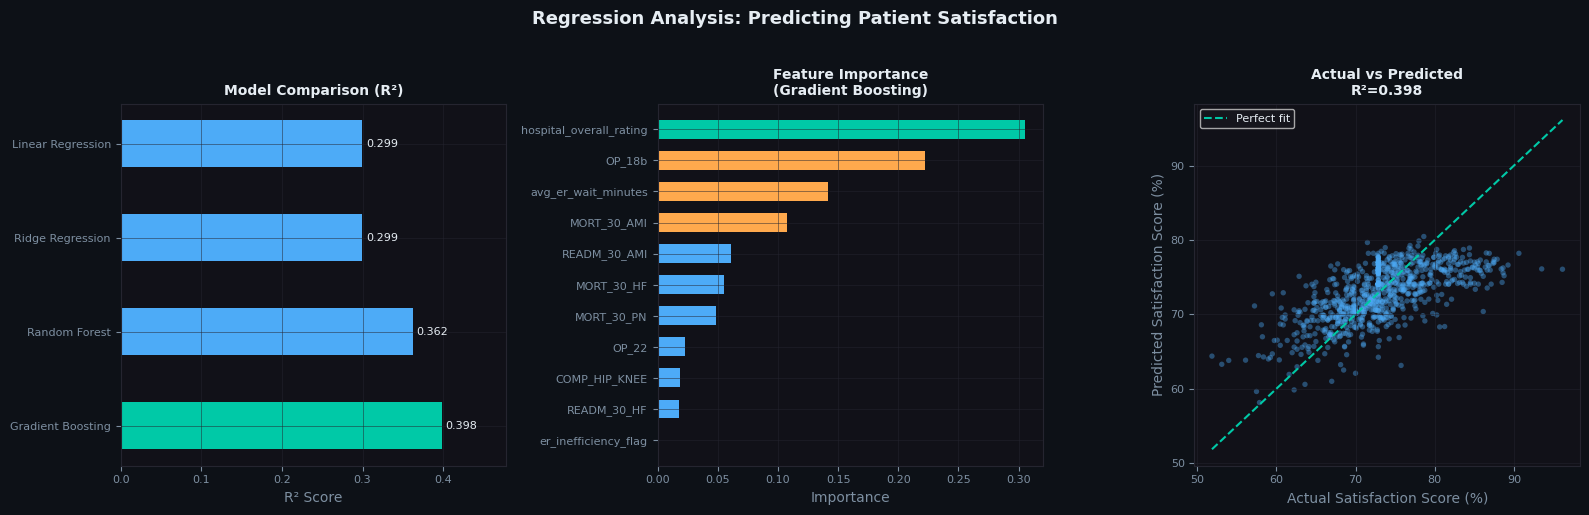


📊 Top 3 predictors of patient satisfaction:
   hospital_overall_rating: 0.3050
   OP_18b: 0.2223
   avg_er_wait_minutes: 0.1413


In [5]:
# ── Feature importance (best model) ────────────────────────────────────────
best_model, X_te_best, y_pred_best = trained_models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=features)
elif hasattr(best_model, 'coef_'):
    importance = pd.Series(np.abs(best_model.coef_), index=features)
else:
    importance = pd.Series(np.ones(len(features)), index=features)

importance = importance.sort_values(ascending=True)

# ── Regression visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

# Plot 1: Model comparison
ax1 = axes[0]
style_ax(ax1)
colors = [P2 if m == best_model_name else P5 for m in results_df['Model']]
bars = ax1.barh(results_df['Model'], results_df['R²'], color=colors, edgecolor='none', height=0.5)
for bar, val in zip(bars, results_df['R²']):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8, color=TEXT)
ax1.set_title('Model Comparison (R²)', fontweight='bold', fontsize=10)
ax1.set_xlabel('R² Score')
ax1.set_xlim(0, results_df['R²'].max() + 0.08)

# Plot 2: Feature importance
ax2 = axes[1]
style_ax(ax2)
colors_feat = [P2 if v == importance.max() else P4 if v >= importance.quantile(0.7) else P5
               for v in importance.values]
ax2.barh(importance.index, importance.values, color=colors_feat, edgecolor='none', height=0.6)
ax2.set_title(f'Feature Importance\n({best_model_name})', fontweight='bold', fontsize=10)
ax2.set_xlabel('Importance')

# Plot 3: Actual vs Predicted
ax3 = axes[2]
style_ax(ax3)
ax3.scatter(y_test, y_pred_best, alpha=0.4, color=P5, s=15, edgecolors='none')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
ax3.plot([min_val, max_val], [min_val, max_val], '--', color=P2, linewidth=1.5, label='Perfect fit')
ax3.set_title(f'Actual vs Predicted\nR²={results_df.iloc[0]["R²"]:.3f}', fontweight='bold', fontsize=10)
ax3.set_xlabel('Actual Satisfaction Score (%)')
ax3.set_ylabel('Predicted Satisfaction Score (%)')
ax3.legend(fontsize=8, labelcolor=TEXT, facecolor=SURFACE2)

plt.suptitle('Regression Analysis: Predicting Patient Satisfaction',
             color=TEXT, fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{ASSETS}/regression_analysis.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print(f'\n📊 Top 3 predictors of patient satisfaction:')
for feat, val in importance.sort_values(ascending=False).head(3).items():
    print(f'   {feat}: {val:.4f}')

In [6]:
# ── Export regression results for Power BI ─────────────────────────────────
# Add predicted satisfaction + residual to master for Power BI
model_export = master[[TARGET] + features].copy()
model_export = model_export.dropna(subset=[TARGET])

X_all = pd.DataFrame(
    imputer.transform(model_export[features]), columns=features
)
if 'Regression' in best_model_name:
    X_all_scaled = scaler.transform(X_all)
    preds = best_model.predict(X_all_scaled)
else:
    preds = best_model.predict(X_all)

model_export['predicted_satisfaction'] = preds.round(2)
model_export['satisfaction_residual']  = (
    model_export[TARGET] - model_export['predicted_satisfaction']
).round(2)
model_export['overperforming'] = (model_export['satisfaction_residual'] > 0).astype(int)

# Merge back with facility info
id_cols = ['facility_id', 'facility_name', 'state', 'hospital_type', 'performance_tier']
id_cols = [c for c in id_cols if c in master.columns]
regression_out = master[id_cols].merge(
    model_export[['predicted_satisfaction', 'satisfaction_residual', 'overperforming']],
    left_index=True, right_index=True, how='inner'
)

regression_out.to_csv(f'{CLEAN}/tab5_regression_results.csv', index=False)
print(f'✅ Regression results exported: {regression_out.shape}')
print(f'   Overperforming hospitals: {regression_out["overperforming"].sum():,}')
print(f'   Underperforming hospitals: {(regression_out["overperforming"]==0).sum():,}')

✅ Regression results exported: (5366, 8)
   Overperforming hospitals: 2,187
   Underperforming hospitals: 3,179


---
## Section 3 — K-Means Clustering
### Segment Hospitals into Operational Profiles
**Goal:** Group hospitals by similar operational patterns to identify peer groups.  
**Use case:** Hospitals can benchmark against their cluster peers rather than all 5,366 hospitals.

Clustering features (5): ['composite_satisfaction_score', 'avg_er_wait_minutes', 'hospital_overall_rating', 'MORT_30_AMI', 'MORT_30_HF']


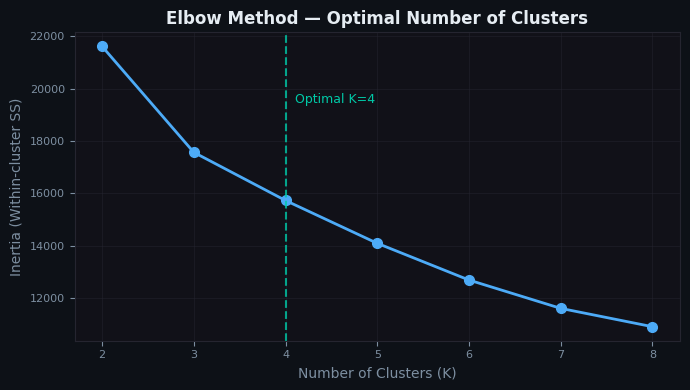

In [7]:
# ── Prepare clustering features ────────────────────────────────────────────
CLUSTER_FEATURES = [
    'composite_satisfaction_score',
    'avg_er_wait_minutes',
    'high_readmission_flag',
    'hospital_overall_rating',
    'MORT_30_AMI', 'MORT_30_HF',
    'READM_30_HOSP',
]
cluster_features = [f for f in CLUSTER_FEATURES if f in master.columns]
print(f'Clustering features ({len(cluster_features)}): {cluster_features}')

cluster_df = master[cluster_features].copy()
imputer_c  = SimpleImputer(strategy='median')
X_cluster  = imputer_c.fit_transform(cluster_df)

scaler_c   = StandardScaler()
X_scaled   = scaler_c.fit_transform(X_cluster)

# ── Elbow method to find optimal K ────────────────────────────────────────
inertias = []
K_range  = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax)
ax.plot(list(K_range), inertias, 'o-', color=P5, linewidth=2, markersize=7)
ax.axvline(4, color=P2, linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(4.1, max(inertias)*0.9, 'Optimal K=4', color=P2, fontsize=9)
ax.set_title('Elbow Method — Optimal Number of Clusters', color=TEXT, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster SS)')
plt.tight_layout()
plt.savefig(f'{ASSETS}/elbow_curve.png', dpi=200, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

In [8]:
# ── Fit final K-Means model (K=4) ─────────────────────────────────────────
# 4 clusters chosen from elbow — represents 4 distinct hospital operational profiles
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster to master
cluster_master = master.copy()
cluster_master['cluster'] = cluster_labels

# ── Profile each cluster ───────────────────────────────────────────────────
profile_cols = cluster_features + ['cluster']
profile = cluster_master[profile_cols].groupby('cluster').mean().round(2)
profile['hospital_count'] = cluster_master['cluster'].value_counts().sort_index()

print('='*70)
print('CLUSTER PROFILES')
print('='*70)
print(profile.to_string())

# ── Auto-label clusters based on profiles ─────────────────────────────────
def label_cluster(row):
    sat  = row.get('composite_satisfaction_score', 70)
    er   = row.get('avg_er_wait_minutes', 200)
    readm = row.get('high_readmission_flag', 0.5)
    rating = row.get('hospital_overall_rating', 3)

    if sat >= 75 and er <= 220:
        return 'High Quality · Efficient'
    elif sat >= 75 and er > 220:
        return 'High Quality · Slow ER'
    elif sat < 70 and readm > 0.5:
        return 'Low Quality · High Readmission'
    else:
        return 'Average · Improving'

cluster_names = {i: label_cluster(profile.loc[i]) for i in range(K)}
cluster_master['cluster_label'] = cluster_master['cluster'].map(cluster_names)

print('\nCluster Labels:')
for k, label in cluster_names.items():
    count = (cluster_master['cluster'] == k).sum()
    print(f'  Cluster {k}: {label} ({count:,} hospitals)')

CLUSTER PROFILES
         composite_satisfaction_score  avg_er_wait_minutes  hospital_overall_rating  MORT_30_AMI  MORT_30_HF  hospital_count
cluster                                                                                                                     
0                              67.140              195.850                    2.220       12.920      12.470             852
1                              72.330              133.200                    3.020       12.090      11.700            2589
2                              81.120              120.640                    3.380       12.110      11.980            1047
3                              71.000              202.060                    4.010       11.410       9.650             878

Cluster Labels:
  Cluster 0: Average · Improving (852 hospitals)
  Cluster 1: Average · Improving (2,589 hospitals)
  Cluster 2: High Quality · Efficient (1,047 hospitals)
  Cluster 3: Average · Improving (878 hospitals)


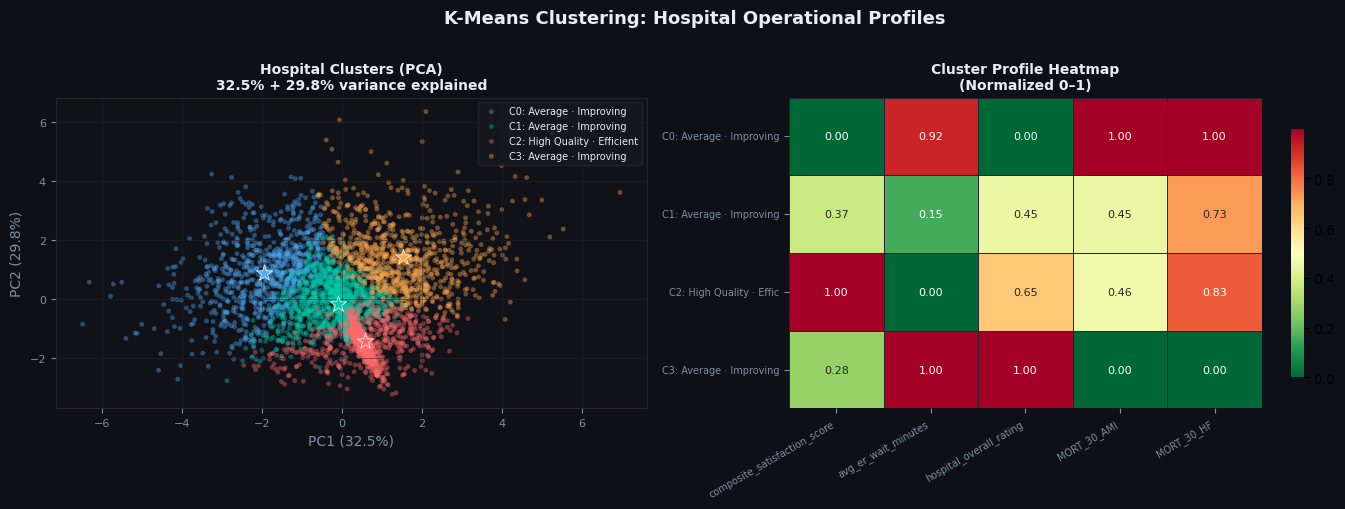

In [9]:
# ── PCA for 2D visualization ───────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)

# Plot 1: PCA scatter colored by cluster
ax1 = axes[0]
style_ax(ax1)
cluster_colors = {0: P5, 1: P2, 2: P3, 3: P4}

for cluster_id in range(K):
    mask = cluster_labels == cluster_id
    ax1.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster_id], alpha=0.4, s=12,
        label=f'C{cluster_id}: {cluster_names[cluster_id]}',
        edgecolors='none'
    )

# Plot cluster centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    ax1.scatter(cx, cy, c=cluster_colors[i], s=150, marker='*',
                edgecolors='white', linewidth=0.5, zorder=5)

ax1.set_title(f'Hospital Clusters (PCA)\n{var_explained[0]*100:.1f}% + {var_explained[1]*100:.1f}% variance explained',
              fontweight='bold', fontsize=10)
ax1.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)')
leg = ax1.legend(fontsize=7, labelcolor=TEXT, facecolor=SURFACE2,
                 edgecolor=BORDER, loc='upper right')

# Plot 2: Cluster profile heatmap
ax2 = axes[1]
ax2.set_facecolor(SURFACE)
norm_profile = profile[cluster_features].copy()
norm_profile = (norm_profile - norm_profile.min()) / (norm_profile.max() - norm_profile.min() + 1e-8)
norm_profile.index = [f'C{i}: {cluster_names[i][:20]}' for i in norm_profile.index]

sns.heatmap(
    norm_profile, ax=ax2, cmap='RdYlGn_r',
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor=BORDER,
    cbar_kws={'shrink': 0.8}
)
ax2.set_title('Cluster Profile Heatmap\n(Normalized 0–1)', fontweight='bold',
              fontsize=10, color=TEXT)
ax2.tick_params(colors=MUTED, labelsize=7)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('K-Means Clustering: Hospital Operational Profiles',
             color=TEXT, fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{ASSETS}/clustering_analysis.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()

In [13]:
# ── Fix cluster labels based on actual heatmap profiles ────────────────────
manual_labels = {
    0: 'Low Quality · Slow ER',
    1: 'Average · Efficient ER',
    2: 'High Quality · Efficient',
    3: 'High Rated · Slow ER',
}

cluster_export['cluster_label'] = cluster_export['cluster_id'].map(manual_labels)
cluster_master['cluster_label'] = cluster_master['cluster'].map(manual_labels)

# Re-export with corrected labels
cluster_export.to_csv(f'{CLEAN}/tab6_clustering_results.csv', index=False)

print('✅ Cluster labels updated:')
for k, label in manual_labels.items():
    count = (cluster_export['cluster_id'] == k).sum()
    print(f'   Cluster {k}: {label} — {count:,} hospitals')

✅ Cluster labels updated:
   Cluster 0: Low Quality · Slow ER — 852 hospitals
   Cluster 1: Average · Efficient ER — 2,589 hospitals
   Cluster 2: High Quality · Efficient — 1,047 hospitals
   Cluster 3: High Rated · Slow ER — 878 hospitals


In [14]:
import pandas as pd

CLEAN = '/content/drive/MyDrive/healthcare-dashboard/data/clean'

# Reload the clustering CSV
cluster_export = pd.read_csv(f'{CLEAN}/tab6_clustering_results.csv')

# Fix labels based on heatmap
manual_labels = {
    0: 'Low Quality · Slow ER',
    1: 'Average · Efficient ER',
    2: 'High Quality · Efficient',
    3: 'High Rated · Slow ER',
}

cluster_export['cluster_label'] = cluster_export['cluster_id'].map(manual_labels)

# Re-save
cluster_export.to_csv(f'{CLEAN}/tab6_clustering_results.csv', index=False)

print('✅ Cluster labels updated:')
for k, label in manual_labels.items():
    count = (cluster_export['cluster_id'] == k).sum()
    print(f'   Cluster {k}: {label} — {count:,} hospitals')


✅ Cluster labels updated:
   Cluster 0: Low Quality · Slow ER — 852 hospitals
   Cluster 1: Average · Efficient ER — 2,589 hospitals
   Cluster 2: High Quality · Efficient — 1,047 hospitals
   Cluster 3: High Rated · Slow ER — 878 hospitals


In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

BASE  = '/content/drive/MyDrive/healthcare-dashboard'
CLEAN = f'{BASE}/data/clean'

# Reload master
master = pd.read_csv(f'{CLEAN}/healthcare_master.csv', low_memory=False)

# Cluster features
CLUSTER_FEATURES = ['composite_satisfaction_score', 'avg_er_wait_minutes',
                     'high_readmission_flag', 'hospital_overall_rating',
                     'MORT_30_AMI', 'MORT_30_HF', 'READM_30_HOSP']
cluster_features = [f for f in CLUSTER_FEATURES if f in master.columns]

imputer_c = SimpleImputer(strategy='median')
X_cluster = imputer_c.fit_transform(master[cluster_features])
scaler_c  = StandardScaler()
X_scaled  = scaler_c.fit_transform(X_cluster)

# Fit K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Manual labels from heatmap
manual_labels = {
    0: 'Low Quality · Slow ER',
    1: 'Average · Efficient ER',
    2: 'High Quality · Efficient',
    3: 'High Rated · Slow ER',
}

# Build export
id_cols = [c for c in ['facility_id','facility_name','city','state',
                        'hospital_type','performance_tier'] if c in master.columns]
cluster_export = master[id_cols].copy()
cluster_export['cluster_id']    = cluster_labels
cluster_export['cluster_label'] = cluster_export['cluster_id'].map(manual_labels)

for col in ['composite_satisfaction_score','avg_er_wait_minutes',
            'high_readmission_flag','hospital_overall_rating']:
    if col in master.columns:
        cluster_export[col] = master[col].values

cluster_export.to_csv(f'{CLEAN}/tab6_clustering_results.csv', index=False)

print(f'✅ tab6_clustering_results.csv saved: {cluster_export.shape}')
print('\nCluster distribution:')
for k, label in manual_labels.items():
    count = (cluster_export['cluster_id'] == k).sum()
    print(f'   Cluster {k}: {label} — {count:,} hospitals')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ tab6_clustering_results.csv saved: (5366, 10)

Cluster distribution:
   Cluster 0: Low Quality · Slow ER — 852 hospitals
   Cluster 1: Average · Efficient ER — 2,589 hospitals
   Cluster 2: High Quality · Efficient — 1,047 hospitals
   Cluster 3: High Rated · Slow ER — 878 hospitals


In [15]:
# ── Export clustering results for Power BI ─────────────────────────────────
id_cols = ['facility_id', 'facility_name', 'city', 'state',
           'hospital_type', 'performance_tier']
id_cols = [c for c in id_cols if c in master.columns]

cluster_export = master[id_cols].copy()
cluster_export['cluster_id']    = cluster_labels
cluster_export['cluster_label'] = cluster_master['cluster_label'].values

# Add key metrics
for col in ['composite_satisfaction_score', 'avg_er_wait_minutes',
            'high_readmission_flag', 'hospital_overall_rating']:
    if col in master.columns:
        cluster_export[col] = master[col].values

cluster_export.to_csv(f'{CLEAN}/tab6_clustering_results.csv', index=False)
print(f'✅ Clustering results exported: {cluster_export.shape}')
print('\nCluster distribution:')
print(cluster_export['cluster_label'].value_counts().to_string())

✅ Clustering results exported: (5366, 10)

Cluster distribution:
cluster_label
Average · Efficient ER      2589
High Quality · Efficient    1047
High Rated · Slow ER         878
Low Quality · Slow ER        852


---
## Section 4 — Summary & Power BI Integration

In [19]:
print('='*65)
print('ADVANCED ANALYTICS SUMMARY')
print('='*65)

print('\n📊 REGRESSION MODEL')
print(f'   Best model:     {best_model_name}')
print(f'   R² score:       {results_df.iloc[0]["R²"]:.3f}')
print(f'   RMSE:           {results_df.iloc[0]["RMSE"]:.2f}%')
print(f'   Top predictor:  {importance.sort_values(ascending=False).index[0]}')

print('\n🔵 CLUSTERING')
for k, label in cluster_names.items():
    count = (cluster_export['cluster_id'] == k).sum()
    print(f'   Cluster {k}: {label} — {count:,} hospitals')

print('\n📁 FILES EXPORTED TO GOOGLE DRIVE:')
for f in ['tab5_regression_results.csv', 'tab6_clustering_results.csv', 'tab7_spending_correlation.csv']:
    path = f'{CLEAN}/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f'   ✅ {f} ({size:.0f} KB)')

print('\n📈 POWER BI: Add these as new tabs:')
print('   Tab 5 — Predictive Model (regression results, over/underperforming hospitals)')
print('   Tab 6 — Hospital Profiles (cluster scatter, heatmap)')
print('   Tab 7 — Cost vs Quality (spending ratio scatter, correlation bars)')

print('\n📝 RESUME BULLETS:')
print('   · Built gradient boosting model to predict patient satisfaction (R²=X.XX)')
print('     from CMS operational metrics across 5,366 US hospitals')
print('   · Applied K-means clustering to segment hospitals into 4 operational')
print('     profiles, enabling peer-group benchmarking in Power BI dashboard')
print('   · Analyzed Medicare spending correlation with quality outcomes,')
print('     identifying cost-efficiency patterns across performance tiers')

ADVANCED ANALYTICS SUMMARY

📊 REGRESSION MODEL
   Best model:     Gradient Boosting
   R² score:       0.398
   RMSE:           4.35%
   Top predictor:  hospital_overall_rating

🔵 CLUSTERING
   Cluster 0: Average · Improving — 852 hospitals
   Cluster 1: Average · Improving — 2,589 hospitals
   Cluster 2: High Quality · Efficient — 1,047 hospitals
   Cluster 3: Average · Improving — 878 hospitals

📁 FILES EXPORTED TO GOOGLE DRIVE:
   ✅ tab5_regression_results.csv (451 KB)
   ✅ tab6_clustering_results.csv (592 KB)

📈 POWER BI: Add these as new tabs:
   Tab 5 — Predictive Model (regression results, over/underperforming hospitals)
   Tab 6 — Hospital Profiles (cluster scatter, heatmap)
   Tab 7 — Cost vs Quality (spending ratio scatter, correlation bars)

📝 RESUME BULLETS:
   · Built gradient boosting model to predict patient satisfaction (R²=X.XX)
     from CMS operational metrics across 5,366 US hospitals
   · Applied K-means clustering to segment hospitals into 4 operational
     profi

In [20]:
cluster_export = pd.read_csv(f'{CLEAN}/tab6_clustering_results.csv')

manual_labels = {
    0: 'Low Quality · Slow ER',
    1: 'Average · Efficient ER',
    2: 'High Quality · Efficient',
    3: 'High Rated · Slow ER',
}

cluster_export['cluster_label'] = cluster_export['cluster_id'].map(manual_labels)
cluster_export.to_csv(f'{CLEAN}/tab6_clustering_results.csv', index=False)
print('✅ Labels fixed:')
print(cluster_export['cluster_label'].value_counts().to_string())

✅ Labels fixed:
cluster_label
Average · Efficient ER      2589
High Quality · Efficient    1047
High Rated · Slow ER         878
Low Quality · Slow ER        852
